In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'torch', 'torchvision']
imports = {'pillow': 'PIL'}
pinned = {}
fallbacks = {'torch': 'torch==2.11.0', 'torchvision': 'torchvision==0.26.0'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'pytorch' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'torch.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Dropout


Let's think briefly about what we
expect from a good predictive model.
We want it to perform well on unseen data.
Classical generalization theory
suggests that to close the gap between
train and test performance,
we should aim for a simple model.
Simplicity can come in the form
of a small number of dimensions.
We explored this when discussing the
monomial basis functions of linear models
in that section.
Additionally, as we saw when discussing weight decay
($\ell_2$ regularization) in that section,
the (inverse) norm of the parameters also
represents a useful measure of simplicity.
Another useful notion of simplicity is smoothness,
i.e., that the function should not be sensitive
to small changes to its inputs.
For instance, when we classify images,
we would expect that adding some random noise
to the pixels should be mostly harmless.

@Bishop.1995 formalized this idea for small additive input noise under
a sum-of-squares loss, where the expected noisy objective is approximated by
a generalized Tikhonov regularizer.
This work drew a clear mathematical connection
between the requirement that a function be smooth (and thus simple),
and the requirement that it be resilient
to perturbations in the input.

Then, @Srivastava.Hinton.Krizhevsky.ea.2014
developed a clever idea for how to apply Bishop's idea
to the internal layers of a network, too.
Their idea, called *dropout*, involves
injecting noise while computing
each internal layer during forward propagation,
and it has become a standard technique
for training neural networks.
The method is called *dropout* because we literally
*drop out* some neurons during training.
Throughout training, on each iteration,
standard dropout consists of zeroing out
some fraction of the nodes in each layer
before calculating the subsequent layer.

To be clear, we are imposing
our own narrative with the link to Bishop.
The original paper on dropout
offers intuition through a surprising
analogy to sexual reproduction.
The authors argue that neural network overfitting
is characterized by a state in which
each layer relies on a specific
pattern of activations in the previous layer,
calling this condition *co-adaptation*.
Dropout, they claim, breaks up co-adaptation
just as sexual reproduction is argued to
break up co-adapted genes.
While such a justification of this theory is certainly up for debate,
the dropout technique itself has proved enduring,
and various forms of dropout are implemented
in most deep learning libraries.

A third perspective, closer to why dropout works, is due to
@Srivastava.Hinton.Krizhevsky.ea.2014 themselves.
A network with $n$ hidden units has $2^n$ possible dropout masks,
each defining a *thinned* subnetwork that shares its weights
with all the others.
On each training step we sample one such mask,
so the gradient update nudges the shared weights
in a direction that helps that particular thinned network.
Running the full network at test time then approximates
*averaging* the predictions of all $2^n$ subnetworks.
(The weight-scaling rule that justifies this is exact only for a
single linear layer; in deeper networks the test-time forward pass
computes something closer to a *geometric* mean
of the subnetworks' predictions.)
From this angle dropout is cheap model averaging,
which motivates why it tends to reduce variance:
ensembles average away the idiosyncrasies of their members.
The analogy is loose rather than literal, though: the $2^n$
subnetworks share a single set of weights and are trained jointly,
not fit independently the way the members of a bagging ensemble are.


The key challenge is how to inject this noise.
One idea is to inject it in an *unbiased* manner
so that the expected value of each layer (while fixing
the others) equals the value it would have taken absent noise.
In Bishop's work, he added Gaussian noise
to the inputs to a linear model.
At each training iteration, he added noise
sampled from a distribution with mean zero
$\epsilon \sim \mathcal{N}(0,\sigma^2)$ to the input $\mathbf{x}$,
yielding a perturbed point $\mathbf{x}' = \mathbf{x} + \epsilon$.
In expectation, $E[\mathbf{x}'] = \mathbf{x}$.

In standard dropout regularization,
one zeros out some fraction of the nodes in each layer
and then *debiases* each layer by normalizing
by the fraction of nodes that were retained (not dropped out).
In other words,
with *dropout probability* $p$,
each intermediate activation $h$ is replaced by
a random variable $h'$ as follows:

$$
\begin{aligned}
h' =
\begin{cases}
    0 & \textrm{ with probability } p \\
    \frac{h}{1-p} & \textrm{ otherwise}
\end{cases}
\end{aligned}
$$

By design, the expectation remains unchanged,
since $E[h'] = p \cdot 0 + (1-p) \cdot \frac{h}{1-p} = h$.
This is why we divide by $1-p$ and by no other constant:
it is the unique factor that restores the original expected value.
This scheme, with the rescaling applied during *training*, is known as
*inverted dropout*, and it is what every modern framework implements. The
original formulation [@Srivastava.Hinton.Krizhevsky.ea.2014] left
activations untouched during training and instead multiplied the weights by
$1-p$ at *test* time. The two are equivalent in expectation, but inverting
moves all of the bookkeeping into training, so the inference code never has
to change, which is exactly why a `Dropout` layer can be a no-op in
evaluation mode.

In [1]:
from d2l import torch as d2l
import torch
from torch import nn

## Dropout in Practice

Recall the MLP with a hidden layer and five hidden units
from the figure.
When we apply dropout to a hidden layer,
zeroing out each hidden unit with probability $p$,
the result can be viewed as a network
containing only a subset of the original neurons.
In the figure, $h_2$ and $h_5$ are removed.
Consequently, the calculation of the outputs
no longer depends on $h_2$ or $h_5$
and their respective gradient also vanishes
when performing backpropagation.
In this way, the calculation of the output layer
cannot be overly dependent on any
one element of $h_1, \ldots, h_5$.

![MLP before and after dropout.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/dropout2.svg)

Typically, we disable dropout at test time,
running the full network with no masking and no rescaling.
(One notable exception, keeping dropout *on* at test time to estimate
prediction uncertainty, is explored in exercise 5.)

## Implementation from Scratch

To implement the dropout function for a single layer,
we must draw as many samples
from a Bernoulli (binary) random variable
as our layer has dimensions,
where the random variable takes value $1$ (keep)
with probability $1-p$ and $0$ (drop) with probability $p$.
One easy way to implement this is to first draw samples
from the uniform distribution $U[0, 1]$.
Then we can keep those nodes for which the corresponding
sample is greater than $p$, dropping the rest.

In the following code, we implement a `dropout_layer` function
that drops out the elements in the tensor input `X`
with probability `dropout`,
rescaling the remainder as described above:
dividing the survivors by `1.0-dropout`.

In [2]:
def dropout_layer(X, dropout):
    assert 0 <= dropout <= 1
    if dropout == 1: return torch.zeros_like(X)
    mask = (torch.rand_like(X) > dropout).to(X.dtype)
    return mask * X / (1.0 - dropout)

We can test out the `dropout_layer` function on a few examples.
In the following lines of code,
we pass our input `X` through the dropout operation,
with probabilities 0, 0.5, and 1, respectively.

In [3]:
X = torch.arange(16, dtype = torch.float32).reshape((2, 8))
print('dropout_p = 0:', dropout_layer(X, 0))
print('dropout_p = 0.5:', dropout_layer(X, 0.5))
print('dropout_p = 1:', dropout_layer(X, 1))

dropout_p = 0: tensor([[ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14., 15.]])
dropout_p = 0.5: tensor([[ 0.,  0.,  0.,  6.,  8., 10., 12.,  0.],
        [ 0., 18., 20., 22., 24.,  0., 28.,  0.]])
dropout_p = 1: tensor([[0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0.]])


### Defining the Model

The model below applies dropout to the output
of each hidden layer (following the activation function).
We can set dropout probabilities for each layer separately.
A common choice is to set
a lower dropout probability closer to the input layer.
We ensure that dropout is only active during training.

In [4]:
class DropoutMLPScratch(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.lin1 = nn.LazyLinear(num_hiddens_1)
        self.lin2 = nn.LazyLinear(num_hiddens_2)
        self.lin3 = nn.LazyLinear(num_outputs)
        self.relu = nn.ReLU()

    def forward(self, X):
        H1 = self.relu(self.lin1(X.reshape((X.shape[0], -1))))
        if self.training:  
            H1 = dropout_layer(H1, self.dropout_1)
        H2 = self.relu(self.lin2(H1))
        if self.training:
            H2 = dropout_layer(H2, self.dropout_2)
        return self.lin3(H2)

### Training

The following is similar to the training of MLPs described previously.
Following the convention above, we drop out
the layer closer to the input more gently
($p = 0.2$) than the deeper one ($p = 0.5$).

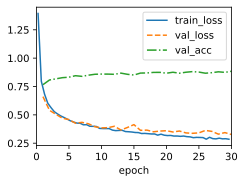

In [5]:
hparams = {'num_outputs':10, 'num_hiddens_1':256, 'num_hiddens_2':256,
           'dropout_1':0.2, 'dropout_2':0.5, 'lr':0.1}
model = DropoutMLPScratch(**hparams)
data = d2l.FashionMNIST(batch_size=256)
trainer = d2l.Trainer(max_epochs=30)
trainer.fit(model, data)

## Concise Implementation

With high-level APIs, all we need to do is add a `Dropout` layer
after each fully connected layer,
passing in the dropout probability
as the only argument to its constructor.
During training, the `Dropout` layer will randomly
drop out outputs of the previous layer
(or equivalently, the inputs to the subsequent layer)
according to the specified dropout probability.
When not in training mode,
the `Dropout` layer simply passes the data through during testing.

In [6]:
class DropoutMLP(d2l.Classifier):
    def __init__(self, num_outputs, num_hiddens_1, num_hiddens_2,
                 dropout_1, dropout_2, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.Flatten(), nn.LazyLinear(num_hiddens_1), nn.ReLU(), 
            nn.Dropout(dropout_1), nn.LazyLinear(num_hiddens_2), nn.ReLU(), 
            nn.Dropout(dropout_2), nn.LazyLinear(num_outputs))

Next, we train the model.

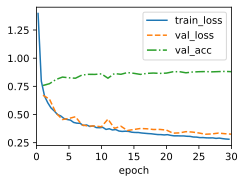

In [7]:
model = DropoutMLP(**hparams)
trainer.fit(model, data)

## Summary

*Inverted dropout* replaces each hidden activation $h$ with a random variable
$h'$ that is zero with probability $p$ and $h/(1-p)$ otherwise. The rescaling by
$1/(1-p)$ keeps $E[h'\mid h] = h$. This is a layerwise statement; after
nonlinear downstream layers, the expected network output under dropout need
not equal the output of the full network. Dropout is *off at test time*: the
full network runs, with no masking and no rescaling.

Three complementary views explain why dropout helps. The first is *noise
injection*: zeroing activations at random injects noise, and by analogy with
Bishop's input-noise result this favors a smoother learned function (the exact
equivalence is proved only for additive input noise, not multiplicative
dropout). The
second is *anti-co-adaptation*: because no hidden unit can count on any specific
partner being present, each unit is pushed to learn broadly useful features. The
third is the *implicit ensemble*: every training step trains a different thinned
subnetwork, and evaluating the full network at test time approximates averaging
the predictions of all $2^n$ of them [@Srivastava.Hinton.Krizhevsky.ea.2014].

A word on currency. Dropout was transformative for the fully connected vision
networks of the mid-2010s, but its role has narrowed since. Convolutional
networks typically replace it with batch normalization (see
that section), which supplies similar noise-driven regularization.
The two also combine poorly: batch normalization's running statistics,
accumulated while dropout perturbs the activations' variance during training,
mismatch the variance it sees at evaluation time, so placing dropout before a
batch-normalization layer tends to hurt [@Li.Chen.Hu.ea.2019].
Large transformer-based language models use dropout lightly (rates around 0.0 to
0.1) or not at all in their core layers, reserving it mostly for final
classifier heads. It nonetheless remains a cheap, reliable regularizer that
combines well with weight decay and data augmentation, and it is the conceptual
seed for a family of stochastic-regularization methods.


## Exercises

1. What happens if you change the dropout probabilities for the first and second layers? In particular, what happens if you switch the ones for both layers? Design an experiment to answer these questions, describe your results quantitatively, and summarize the qualitative takeaways.
1. Train the same architecture without dropout for the same number of epochs. Plot the train and test loss curves for both runs on the same axes. How wide is the train/test gap with and without dropout?
1. What is the variance of the activations in each hidden layer when dropout is and is not applied? Draw a plot to show how this quantity evolves over time for both models.
1. Why is dropout not typically used at test time?
1. *Monte Carlo dropout.* At test time, instead of disabling dropout, keep it on and run $T = 20$ forward passes per example, then average the softmax outputs. Compare the resulting accuracy and the calibration (predicted confidence versus actual accuracy) against the standard single-pass evaluation. How does this procedure relate to ensemble methods? (See @Gal.Ghahramani.2016.)
1. Using the model in this section as an example, compare the effects of using dropout and weight decay. What happens when dropout and weight decay are used at the same time? Are the results additive? Are there diminished returns (or worse)? Do they cancel each other out?
1. What happens if we apply dropout to the individual weights of the weight matrix rather than the activations? (This variant is known as *DropConnect* [@Wan.Zeiler.Zhang.LeCun.Fung.2013].) Implement it and compare it against standard dropout on Fashion-MNIST, holding the architecture and training budget fixed.
1. Invent another technique for injecting random noise at each layer that differs from both dropout and DropConnect, for example adding Gaussian noise to the activations. For a fixed architecture and training budget, can you develop a method that matches or outperforms dropout on Fashion-MNIST?

[Discussions](https://d2l.discourse.group/t/101)